# Period-2 regime (r = 3.2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_dynamics(r, x0=0.1, n_iter=50, interval=100):
    # 1. Setup Figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # --- COBWEB SETUP (Left) ---
    xs = np.linspace(0, 1, 500)
    ax1.plot(xs, r * xs * (1 - xs), 'k', lw=1.2, label=f"$f(x) = {r}x(1-x)$")
    ax1.plot(xs, xs, 'k--', alpha=0.4, label="$y=x$")
    cobweb_line, = ax1.plot([], [], 'r-', lw=1, alpha=0.8)
    cobweb_dot, = ax1.plot([], [], 'ro', markersize=5)
    ax1.set_title(f"Cobweb Plot (r={r})")
    ax1.set_xlim(0, 1), ax1.set_ylim(0, 1)
    ax1.set_xlabel("$x_t$"), ax1.set_ylabel("$x_{t+1}$")

    # --- TIME SERIES SETUP (Right) ---
    ts_line, = ax2.plot([], [], 'b-o', lw=1.5, markersize=4, alpha=0.7)
    ax2.set_title("Time Series")
    ax2.set_xlim(0, n_iter)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("Time (t)")
    ax2.set_ylabel("Value ($x_t$)")
    ax2.grid(True)

    # 2. Calculate Data
    px, py = [x0], [0]     # Cobweb coordinates
    tx, ty = [0], [x0]     # Time series coordinates (t, x_t)

    curr_x = x0
    for t in range(1, n_iter + 1):
        y_next = r * curr_x * (1 - curr_x)
        # Cobweb steps: vertical then horizontal
        px.extend([curr_x, curr_x, y_next])
        py.extend([curr_x, y_next, y_next])
        # Time series steps: one point per iteration
        tx.append(t)
        ty.append(y_next)
        curr_x = y_next

    # 3. Animation Logic
    def update(frame):
        # Update Cobweb (3 points per iteration in our px/py lists)
        cob_idx = frame * 3
        cobweb_line.set_data(px[:cob_idx], py[:cob_idx])
        if cob_idx > 0:
            cobweb_dot.set_data([px[cob_idx-1]], [py[cob_idx-1]])

        # Update Time Series
        ts_line.set_data(tx[:frame+1], ty[:frame+1])

        return cobweb_line, cobweb_dot, ts_line

    ani = FuncAnimation(fig, update, frames=n_iter + 1, interval=interval, blit=True)
    plt.tight_layout()
    plt.close(fig)
    return ani



In [2]:
# To display in Jupyter/Colab:
from IPython.display import HTML
HTML(animate_dynamics(r=3.2, n_iter=30).to_jshtml())

#  Period-4 regime (r = 3.5)

In [3]:
HTML(animate_dynamics(r=3.5, n_iter=30).to_jshtml())

knowing:

In [4]:
def logistic_step(x, r):
    return r * x * (1 - x)


Step 1. Choose a grid of parameter values `r`

In [5]:
r_min, r_max = 2.5, 3.565
n_r = 3000
r_values = np.linspace(r_min, r_max, n_r)


Step 2. Set iteration settings (transients vs long-run)

*   n_transient: iterations to discard (early dynamics)
*   n_keep: iterations to plot (attractor)

In [6]:
n_transient = 800
n_keep = 200


Step 3. Iterate the system for each $r$:

In [7]:
x0 = 0.2  # initial condition (fixed for all r)

Rs = []
Xs = []

for r in r_values:
    x = x0

    # 3a) burn-in (remove transient dynamics)
    for _ in range(n_transient):
        x = logistic_step(x, r)

    # 3b) record long-run values (attractor)
    for _ in range(n_keep):
        x = logistic_step(x, r)
        Rs.append(r)
        Xs.append(x)

Rs = np.array(Rs) # repeated r-values (one for each plotted point)
Xs = np.array(Xs) # the corresponding long-run 𝑥t values

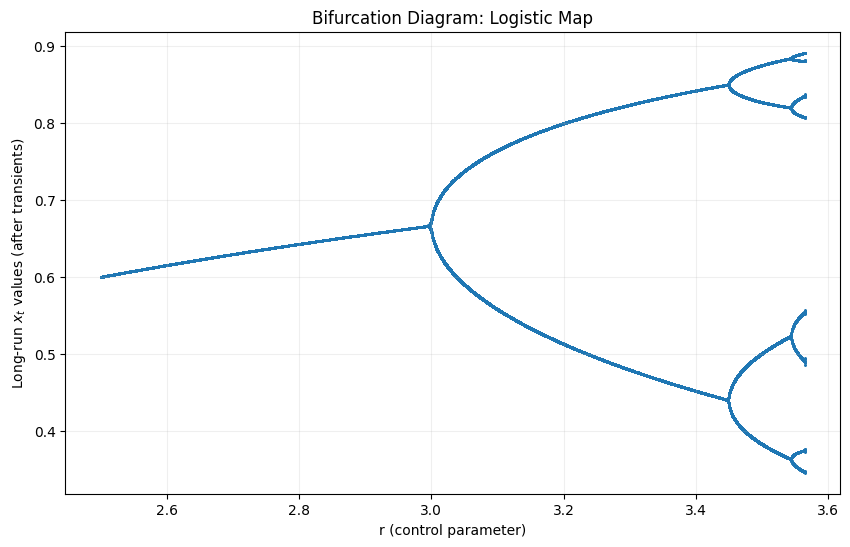

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(Rs, Xs, s=0.2, alpha=0.6)
plt.xlabel("r (control parameter)")
plt.ylabel(r"Long-run $x_t$ values (after transients)")
plt.title("Bifurcation Diagram: Logistic Map")
plt.grid(alpha=0.2)
plt.show()
